# 03 — Classical ML (Phase 2 minimal pipeline)

**Phase 2 exit criterion.** A single call to `train_and_evaluate` runs the full
pipeline end-to-end and saves every standard artifact (metrics CSV row, JSON
manifest, confusion matrix, ROC curve). Here we use Logistic Regression on UCI;
in Phase 3 the *same call* drives the full model line-up — a one-line swap.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import json

import pandas as pd
from sklearn.linear_model import LogisticRegression
from IPython.display import Image, display

from src.config import (
    RANDOM_SEED, METRICS_ML_CSV, MANIFESTS_DIR, CONFUSION_MATRICES_DIR, ROC_CURVES_DIR,
)
from src.experiments.runner import train_and_evaluate
print("setup ok")

setup ok


## 1. Run the end-to-end pipeline

In [2]:
metrics = train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    dataset="uci",
)
metrics

2026/06/23 23:56:45 INFO mlflow.tracking.fluent: Experiment with name 'phishing-detection' does not exist. Creating a new experiment.


[LogisticRegression_uci_20260623_235643] acc=0.9361 f1=0.9276 recall=0.9238 auc=0.9809
  manifest -> results/manifests/LogisticRegression_uci_20260623_235643.json


{'accuracy': 0.9361060880048222,
 'precision': 0.9314128943758574,
 'recall': 0.9238095238095239,
 'f1': 0.9275956284153005,
 'auc_roc': 0.9808883293577171}

## 2. The standardized metrics row (§8.2)

`train_and_evaluate` appended a row to `results/metrics_ml.csv` — the source of truth for the comparison charts in Phase 7.

In [3]:
pd.read_csv(METRICS_ML_CSV)

,model,dataset,accuracy,precision,recall,f1,auc_roc,train_time_s,inference_time_ms_per_sample
0,LogisticRegression,uci,0.9361,0.9314,0.9238,0.9276,0.9809,0.0359,0.001105


## 3. Saved diagnostics — confusion matrix & ROC (300 DPI)

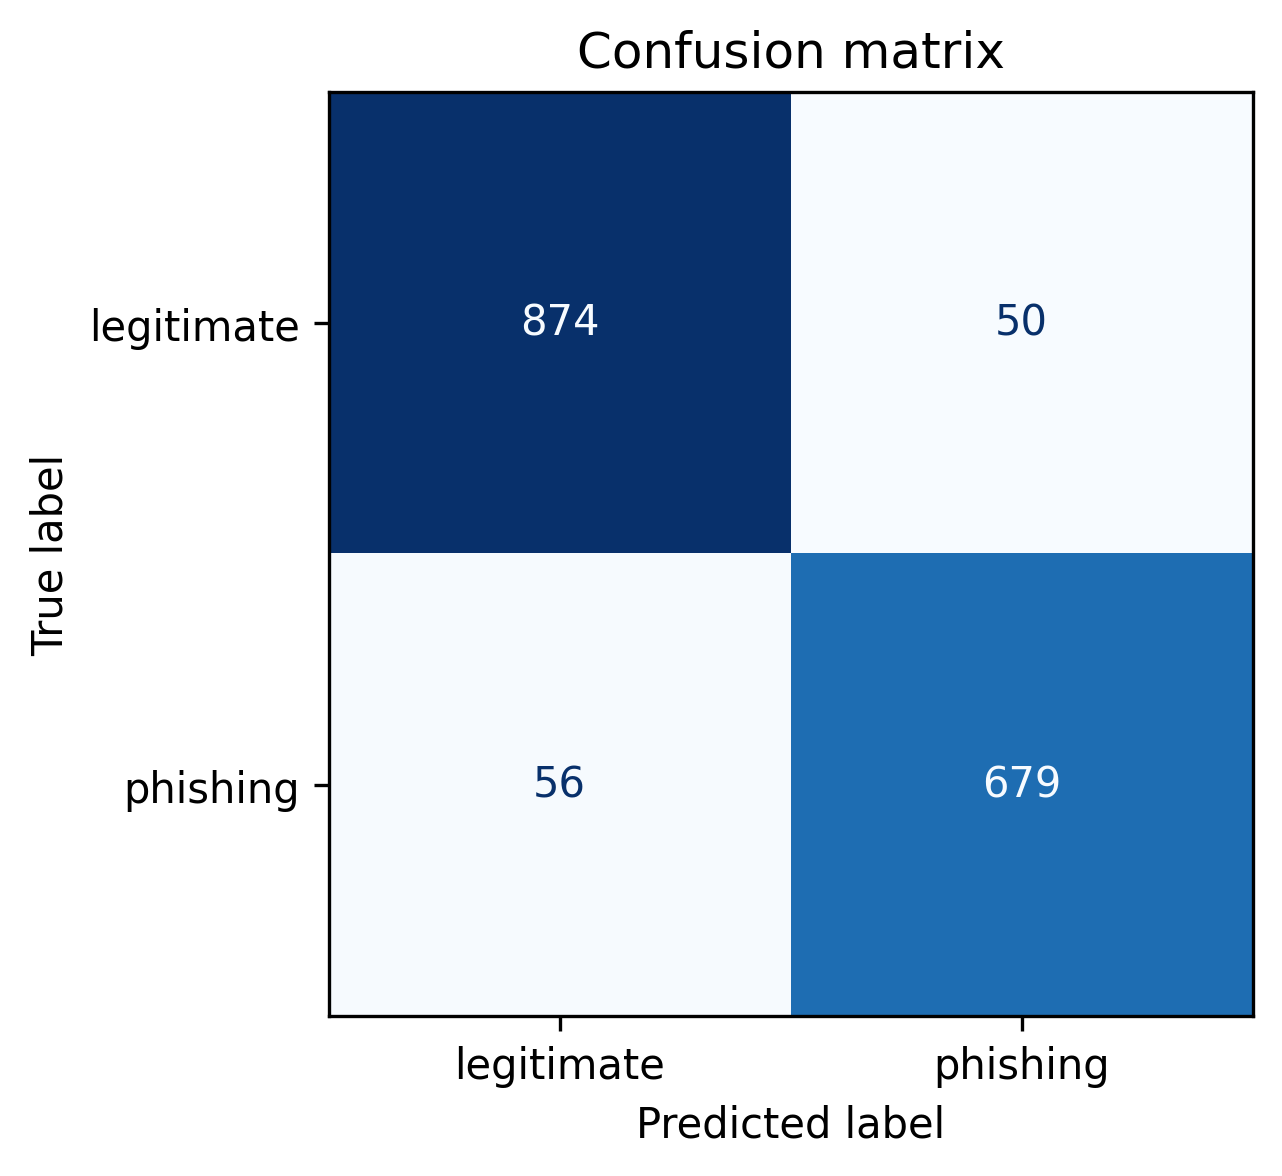

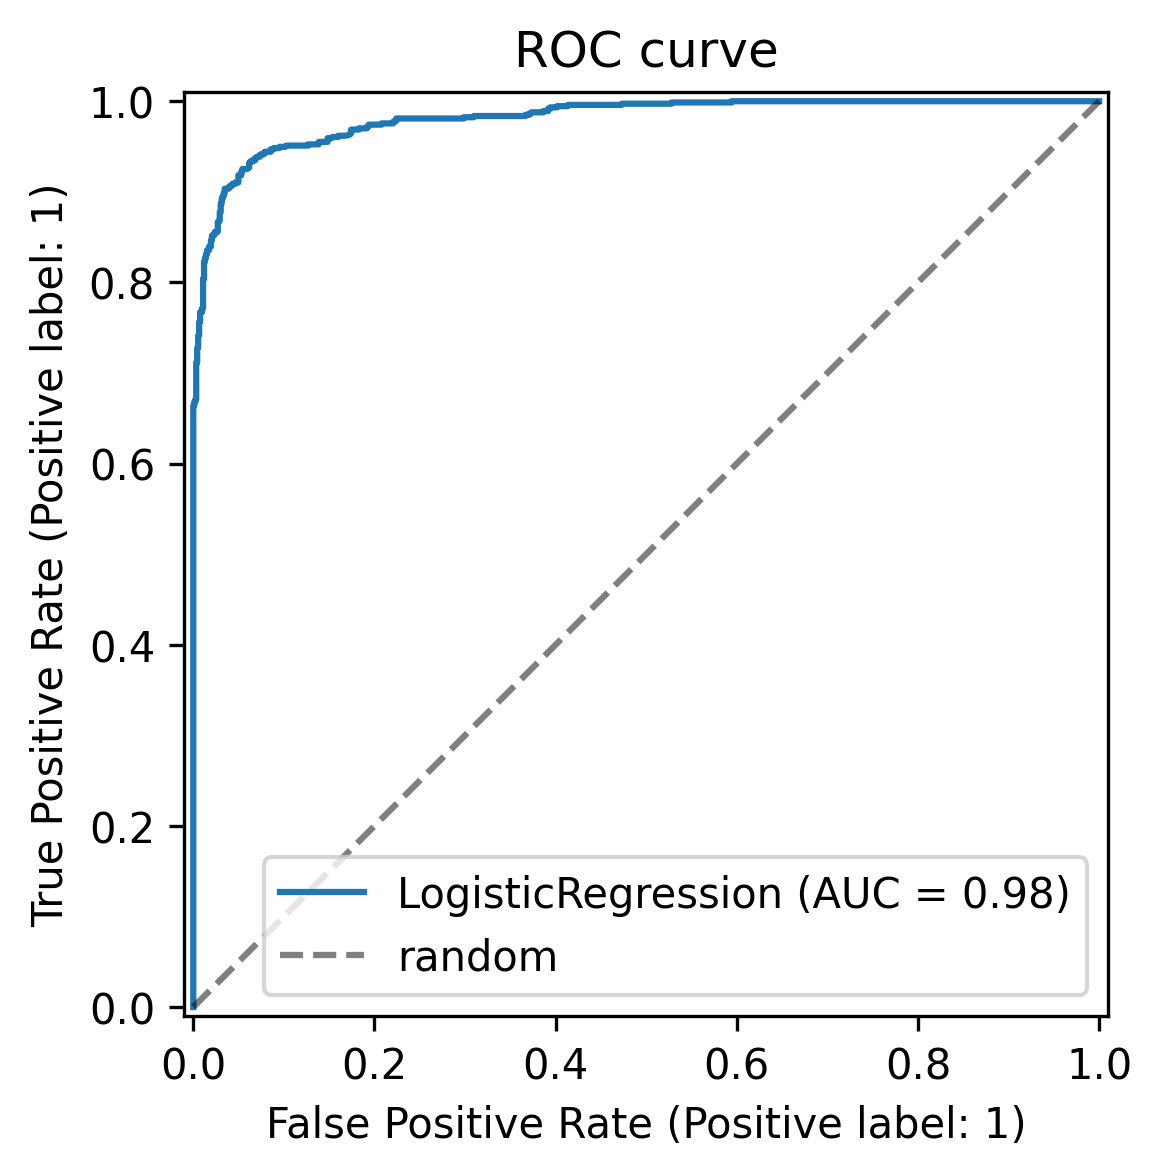

In [4]:
display(Image(filename=str(CONFUSION_MATRICES_DIR / "LogisticRegression_uci.png")))
display(Image(filename=str(ROC_CURVES_DIR / "LogisticRegression_uci.png")))

## 4. The experiment manifest (§6.4)

Full provenance: dataset hash, git commit, seed, library versions, metrics, cost.

In [5]:
latest = max(MANIFESTS_DIR.glob("*.json"), key=lambda p: p.stat().st_mtime)
print(latest.name, "\n")
print(json.dumps(json.loads(latest.read_text()), indent=2))

LogisticRegression_uci_20260623_235643.json 

{
  "experiment_id": "LogisticRegression_uci_20260623_235643",
  "timestamp": "2026-06-23T23:56:44.584603-03:00",
  "model": "LogisticRegression",
  "dataset": "uci",
  "dataset_hash": "685e9fbdbe08c8b23fdb82e06cf5e154a8516e93f7b07f8a67328f17f86d0d72",
  "git_commit": "e1255f6",
  "seed": 42,
  "hyperparameters": {
    "C": 1.0,
    "class_weight": null,
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": null,
    "max_iter": 1000,
    "multi_class": "deprecated",
    "n_jobs": null,
    "penalty": "l2",
    "random_state": 42,
    "solver": "lbfgs",
    "tol": 0.0001,
    "verbose": 0,
    "warm_start": false
  },
  "library_versions": {
    "python": "3.11.15",
    "scikit-learn": "1.5.2",
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "imbalanced-learn": "0.12.4",
    "xgboost": "2.1.1",
    "torch": "2.4.1"
  },
  "metrics": {
    "accuracy": 0.9361060880048222,
    "precision": 0.93141289437585

## 5. Exit criterion ✓

One call produced a complete CSV row, a JSON manifest, a confusion matrix, and a ROC curve — all in standard locations. The pipeline is ready for the full classical line-up (Phase 3).